# Hafta 3 · Ders 6 — En Küçük Kareler ve Normal Denklemler

> **Makine Öğrenmesi için Lineer Cebir** · ilk ilkelerden bir kurs
>
> *türet → uygula → görselleştir → doğrula → makine öğrenmesine bağla*

Gerçek veri kümeleri bize **bilinmeyenlerden daha fazla denklem** verir: yüzlerce veri noktası, bir avuç
parametre. $X\boldsymbol\beta = \mathbf{y}$ sisteminin *kesin* bir çözümü yoktur — hiçbir doğru her
noktadan geçmez. Bu yüzden bir sonraki en iyi şeyi isteriz: **mümkün olduğunca yakın** olan
$\boldsymbol\beta$.

"Mümkün olduğunca yakın", karesel hatayı en aza indirmek demektir ve geometri güzeldir: en iyi
uyum, $\mathbf{y}$'nin $X$'in **sütun uzayına** **izdüşümüdür**. Bu tek fikir — Ders 2'yi (izdüşüm)
ve Ders 4'ü (sütun uzayı) birleştirerek — lineer regresyonun *kendisidir*.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.linalg_viz import check

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Problem: çözülemez bir sistem

Gürültülü verilere $y = \beta_0 + \beta_1 x$ doğrusunu uydurmak istediğimizi varsayalım. Denklemleri
üst üste koymak şunu verir

$$ X\boldsymbol\beta = \mathbf{y}, \qquad X = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_m \end{bmatrix} $$

$m$ nokta ve 2 parametre ile $X$ uzundur — tüm satırları sağlayan bir $\boldsymbol\beta$ yoktur.
Geometrik olarak, $\mathbf{y}$ $\mathbb{R}^m$'de yaşar ama ulaşılabilir çıktılar $X\boldsymbol\beta$
yalnızca 2 boyutlu **sütun uzayını** doldurur. $\mathbf{y}$ neredeyse hiçbir zaman o düzleme düşmez.

X shape: (30, 2)  (30 equations, 2 unknowns → overdetermined)


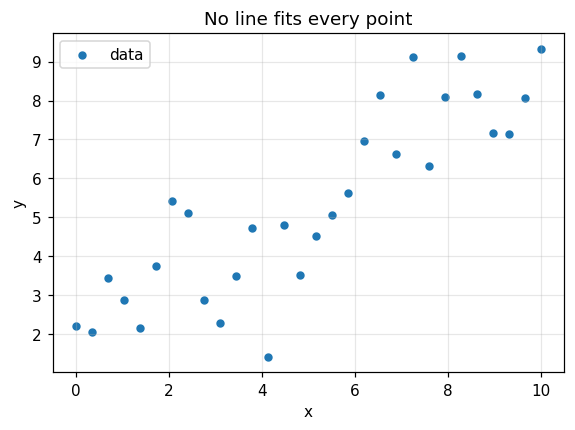

In [2]:
rng = np.random.default_rng(0)
x = np.linspace(0, 10, 30)
y = 2.0 + 0.7 * x + rng.normal(scale=1.5, size=x.size)   # gerçek doğru + gürültü

X = np.column_stack([np.ones_like(x), x])                # tasarım matrisi [1, x]
print("X boyutu:", X.shape, " (30 denklem, 2 bilinmeyen → aşırı belirtilmiş)")

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=20, color="C0", label="veri")
plt.xlabel("x"); plt.ylabel("y"); plt.title("Hiçbir doğru her noktaya uymaz")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

## 2. Geometrik çözüm: y'yi sütun uzayına izdüşür

Sütun uzayında $\mathbf{y}$'ye en yakın noktayı istiyoruz. Ders 2'den, en yakın nokta
**ortogonal izdüşümdür**: kalıntı $\mathbf{y} - X\boldsymbol\beta$, $X$'in *her* sütununa dik
olmalıdır. "Tüm sütunlara dik"i $X^\top(\mathbf{y} - X\boldsymbol\beta) = \mathbf{0}$ olarak yazıp
yeniden düzenlemek, **normal denklemleri** verir:

$$ \boxed{\,X^\top X\,\boldsymbol\beta = X^\top \mathbf{y}\,} $$

Bu artık $\boldsymbol\beta$ cinsinden *kare* bir sistemdir — tam olarak geçen derste çözmeyi öğrendiğimiz
türden. Hiç türev gerekmez; ortogonallik koşulu onu doğrudan verir.

In [3]:
def fit_least_squares(X, y):
    # X^T X beta = X^T y'yi çöz  (açık bir ters yerine kararlı bir çözücü kullanarak)
    A = X.T @ X
    b = X.T @ y
    return np.linalg.solve(A, b)

beta = fit_least_squares(X, y)
print("kesişim β0 =", round(beta[0], 3), " (gerçek ≈ 2.0)")
print("eğim    β1 =", round(beta[1], 3), " (gerçek ≈ 0.7)")

# çözümü tanımlayan ortogonallik koşulunu doğrula
resid = y - X @ beta
print("\nXᵀ · kalıntı =", X.T @ resid, " → ≈ 0, kalıntı ⟂ sütun uzayı ✓")

intercept β0 = 1.89  (true ≈ 2.0)
slope     β1 = 0.686  (true ≈ 0.7)

Xᵀ · residual = [ 0. -0.]  → ≈ 0, residual ⟂ column space ✓


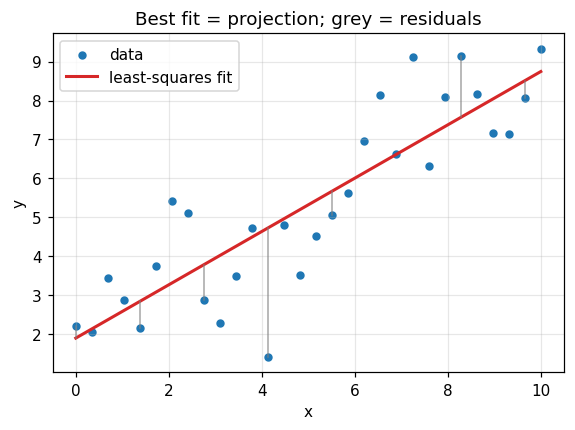

In [4]:
plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=20, color="C0", label="veri")
grid = np.linspace(0, 10, 100)
plt.plot(grid, beta[0] + beta[1] * grid, color="C3", lw=2, label="en küçük kareler uyumu")
# birkaç kalıntıyı, oldukları ortogonal izdüşümler olarak çiz
for xi, yi in zip(x[::4], y[::4]):
    plt.plot([xi, xi], [yi, beta[0] + beta[1] * xi], color="grey", lw=1, alpha=0.7)
plt.xlabel("x"); plt.ylabel("y"); plt.title("En iyi uyum = izdüşüm; gri = kalıntılar")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

## 3. NumPy ve sklearn-tarzı uydurmaya karşı doğrulama

`np.linalg.lstsq` aynı problemi daha sağlam biçimde çözer (içeride QR/SVD ile — Hafta 4 ve 6). Elle
yazılmış normal-denklem çözümümüz, iyi koşullanmış verilerde onunla eşleşmelidir.

In [5]:
beta_np, *_ = np.linalg.lstsq(X, y, rcond=None)
check("bizim β vs np.linalg.lstsq", beta, beta_np)

# R^2, standart regresyon skoru, sıfırdan
def r_squared(y, y_hat):
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

print("R² =", round(r_squared(y, X @ beta), 4))

[PASS] our β vs np.linalg.lstsq         max|Δ| = 3.33e-15
R² = 0.74


## 4. Tek seferde birden fazla öznitelik

Normal denklemlerle ilgili hiçbir şey tek bir öznitelikle sınırlı değildir. $X$'e sütunlar ekleyin ve
*aynı* formül bir hiperdüzlem uydurur. Burada, yöntemin değişiklik olmadan ölçeklendiğini doğrulamak
için $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2$'yi uyduruyoruz.

In [6]:
rng = np.random.default_rng(2)
n = 200
x1 = rng.normal(size=n)
x2 = rng.normal(size=n)
y_multi = 1.0 - 2.0 * x1 + 0.5 * x2 + rng.normal(scale=0.3, size=n)

X_multi = np.column_stack([np.ones(n), x1, x2])
beta_multi = fit_least_squares(X_multi, y_multi)
print("uydurulan katsayılar:", beta_multi)
print("gerçek katsayılar    : [ 1.   -2.    0.5 ]")
print("R² =", round(r_squared(y_multi, X_multi @ beta_multi), 4))

fitted coefficients: [ 0.963  -1.9929  0.4994]
true coefficients  : [ 1.   -2.    0.5 ]
R² = 0.9788


## 5. Bunun makine öğrenmesinde karşımıza çıktığı yer — ve nerede bozulduğu

- **Lineer regresyon** kelimenin tam anlamıyla budur. Lojistik regresyon, birçok ağın son katmanı
  ve çekirdek ridge regresyonu, hepsi aynı izdüşüm fikri üzerine kuruludur.
- **Tehlike:** $X^\top X$ oluşturmak, **koşul sayısının karesini alır** (Ders 5). Korelasyonlu
  özniteliklerle neredeyse tekil hâle gelir ve çözüm patlar. Bu kırılganlık, uygulayıcıların neden
  QR (Hafta 4) ve SVD (Hafta 6) yollarını tercih ettiğinin ve **ridge regresyonunun** neden kararlılaştırıcı
  bir terim eklediğinin nedenidir.

Hadi kararsızlığı ortaya çıkaralım ki sonraki düzeltmeler gerekli hissettirsin.

In [7]:
# neredeyse-özdeş iki öznitelik → X^T X neredeyse tekildir
rng = np.random.default_rng(3)
a = rng.normal(size=100)
X_collinear = np.column_stack([np.ones(100), a, a + 1e-4 * rng.normal(size=100)])
y_c = 3 + 2 * a + rng.normal(scale=0.1, size=100)

print("κ(X)      =", f"{np.linalg.cond(X_collinear):.2e}")
print("κ(XᵀX)    =", f"{np.linalg.cond(X_collinear.T @ X_collinear):.2e}  ← karesi alındı!")

beta_c = fit_least_squares(X_collinear, y_c)
print("\nkararsız katsayılar:", beta_c)
print("iki eşdoğrusal öznitelik çılgın, zıt ağırlıklar alır — ridge'in düzelteceği bir tehlike işareti.")

κ(X)      = 2.18e+04
κ(XᵀX)    = 4.77e+08  ← squared!

unstable coefficients: [   3.0032 -162.1606  164.17  ]
the two collinear features get wild, opposing weights — a red flag ridge will fix.


## Alıştırmalar

1. **Polinom uyumu.** $[1, x, x^2, x^3]$ sütunlarıyla $X$ oluşturun ve gürültülü verilere bir kübik uydurun — aynı normal denklemler, daha zengin model.
2. **Kesişimsiz model.** Birler sütununu çıkarın ve yeniden uydurun. Uyum nasıl değişir ve sıfır-kesişimli bir model ne zaman uygundur?
3. **Kalıntı ortalaması.** Bir kesişim sütunu varken kalıntıların sıfıra toplandığını kanıtlayın (ve kontrol edin). Ortogonallik koşulu bunu neden garanti eder?

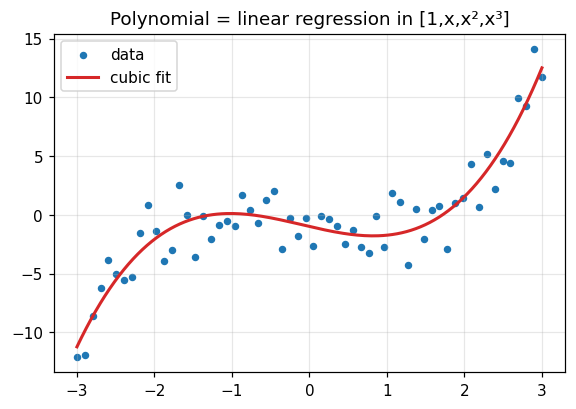

sum of residuals ≈ -0.0


In [8]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. polinom regresyonu, dönüştürülmüş özniteliklerde lineer regresyondur
rng = np.random.default_rng(5)
xp = np.linspace(-3, 3, 60)
yp = 0.5 * xp**3 - xp + rng.normal(scale=2, size=xp.size)
Xp = np.column_stack([xp**k for k in range(4)])     # [1, x, x^2, x^3]
beta_p = fit_least_squares(Xp, yp)
plt.figure(figsize=(6, 4))
plt.scatter(xp, yp, s=15, color="C0", label="veri")
g = np.linspace(-3, 3, 200)
plt.plot(g, np.column_stack([g**k for k in range(4)]) @ beta_p, color="C3", lw=2, label="kübik uyum")
plt.legend(); plt.grid(True, alpha=0.3); plt.title("Polinom = [1,x,x²,x³]'te lineer regresyon")
plt.show()

# 3. bir kesişimle, Xᵀr = 0 tümü-birler satırını içerir ⇒ toplam(kalıntılar) = 0
resid = yp - Xp @ beta_p
print("kalıntıların toplamı ≈", round(resid.sum(), 10))

## Özet ve sırada ne var

Aşırı belirtilmiş sistemlerin kesin çözümü yoktur, bu yüzden $\mathbf{y}$'yi sütun uzayına izdüşürürüz;
kalıntının ortogonalliği, lineer regresyonun *kendisi* olan normal denklemleri
$X^\top X\boldsymbol\beta = X^\top\mathbf{y}$ verir. Ama koşul sayısının karesini almak bu yolu kırılgan yapar.

**Sırada — `07_ortogonallik_gram_schmidt.ipynb`:** izdüşümü önemsiz ve sayısal olarak kararlı yapan
**ortonormal bazlar** inşa ediyoruz — az önce ortaya çıkardığımız kararsızlığın çaresi ve QR ayrışımının
temeli.

---
*Makine Öğrenmesi için Lineer Cebir · Hafta 3 · Ders 6*